<a href="https://colab.research.google.com/github/alracey/level4-project/blob/Higher-dimensions/piecewise_linear_pytorch_2d_opt_bins_coupling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preliminaries

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sympy
#!pip install --upgrade sympy


#get Times New Roman
'''
import matplotlib.font_manager as fm

!wget -O TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
font_dirs = ["/content/"]
font_files = fm.findSystemFonts(fontpaths=font_dirs, fontext='ttf')
for font_file in font_files:
    print(font_file) if 'TimesNewRoman' in font_file else None
    fm.fontManager.addfont(font_file)

plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['font.family'] = "serif"

plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
'''

torch.__version__

'2.10.0+cpu'

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
dtype = torch.float32

Using device: cpu


NOTE: in this piecewise-linear notebook, any instance of the word 'heights' refers to CDF heights and NOT pdf heights because of the way the code is written.

This section defines the target functions f, the piecewise transform g, and the transformed function h.

In [ ]:
sigma = 0.2

In [ ]:
def camel(x, y):
  alpha = 0.2
  peak_1 = torch.exp(-(((x-1/4)**2 + (y-1/4)**2) / alpha**2))
  peak_2 = torch.exp(-(((x-3/4)**2 + (y-3/4)**2) / alpha**2))

  return (0.5 * (alpha * torch.sqrt(torch.tensor(torch.pi)))**(-2)) * (peak_1 + peak_2)

In [ ]:
def f_3d(x, y, z):
  return torch.exp(-(((x-0.5)**2 + (y-0.5)**2 + (z-0.5)**2) / (2*(sigma)**2)))

In [ ]:
def gauss(x, y):
  return torch.exp(-(((x-0.5)**2 + (y-0.5)**2) / (2*(sigma)**2)))

In [ ]:
def ring(x, y, r0=0.3, sigma = 0.05, centre=(0.5, 0.5)):

  cx, cy = centre
  r = torch.sqrt((x-cx)**2 + (y-cy)**2)
  return torch.exp(-((r-r0)**2 / (2*(sigma)**2)))


tensor(1.1129)


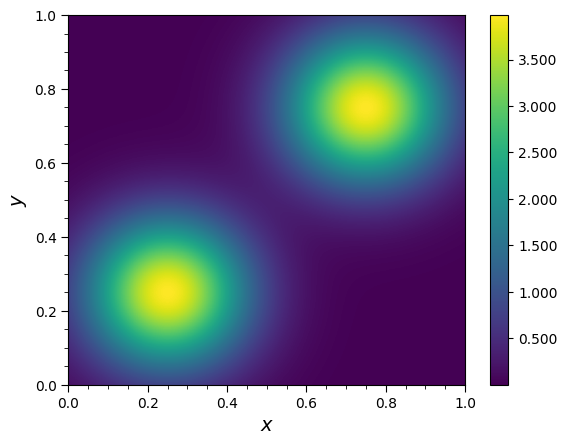

In [ ]:
def plot_f(f, N):
  xs, ys = torch.linspace(0, 1, N), torch.linspace(0, 1, N)
  X, Y = torch.meshgrid(xs, ys, indexing='ij')
  Z = f(X, Y)
  print(torch.var(Z))

  fig, ax = plt.subplots()

  pcm = plt.pcolormesh(X, Y, Z, cmap='viridis', shading='auto')

  ax.set_xlabel("$x$", fontsize=14)
  ax.set_ylabel("$y$", fontsize=14)

  ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=10)
  ax.tick_params(axis="both", which="minor", direction="out", length=3)
  ax.minorticks_on()

  cbar = plt.colorbar(pcm, ax=ax)
  cbar.formatter = ticker.FormatStrFormatter('%.3f')
  cbar.update_ticks()

  ax.set_xlim(0.0, 1.0)
  ax.set_ylim(0.0, 1.0)

  plt.show()
  return fig

test = plot_f(camel, 1000)

tensor(0.1111)


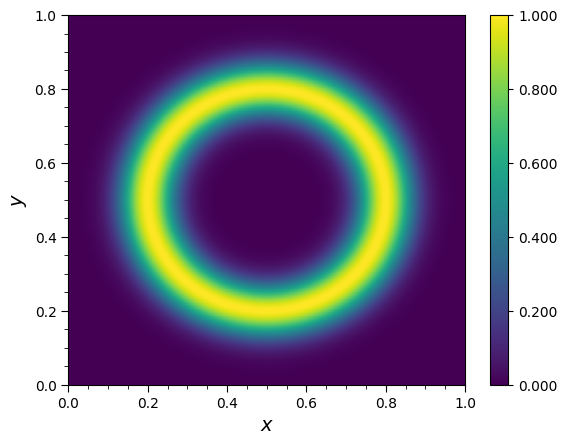

In [ ]:
test_2 = plot_f(ring, 1000)

In [ ]:
def grid_points(n, density):

  npts = n
  grid = torch.empty(density*npts,2)

  for vi in range(int(density/2)):
    beg = vi*npts
    end = beg+npts
    grid[beg:end,0] = vi/int(((density/2) - 1))
    grid[beg:end,1] = torch.linspace(0, 1, npts)

  for hi in range(int(density/2)):
    beg = (int(density/2)+hi)*npts
    end = beg+npts
    grid[beg:end,1] = hi/int(((density/2)-1))
    grid[beg:end,0] = torch.linspace(0, 1, npts)

  return grid

In [ ]:
def plot_f_scatter(f, n, density):

  fig, ax = plt.subplots(figsize=(7.5,6))
  points = grid_points(n, density)
  x = points[:,0]
  y = points[:,1]
  z = f(x, y)

  scat = ax.scatter(
    x,
    y,
    c=z,
    s=6,
    cmap='viridis'
  )
  #ax.set_xlabel("$x$", fontsize=14)
  #ax.set_ylabel("$y$", fontsize=14)

  ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=16)
  ax.tick_params(axis="both", which="minor", direction="out", length=3)
  ax.minorticks_on()

  cbar = plt.colorbar(scat, ax=ax)
  cbar.formatter = ticker.FormatStrFormatter('%.2f')
  cbar.ax.tick_params(labelsize=16)
  cbar.update_ticks()

  ax.set_xlim(0.0, 1.0)
  ax.set_ylim(0.0, 1.0)

  plt.show()

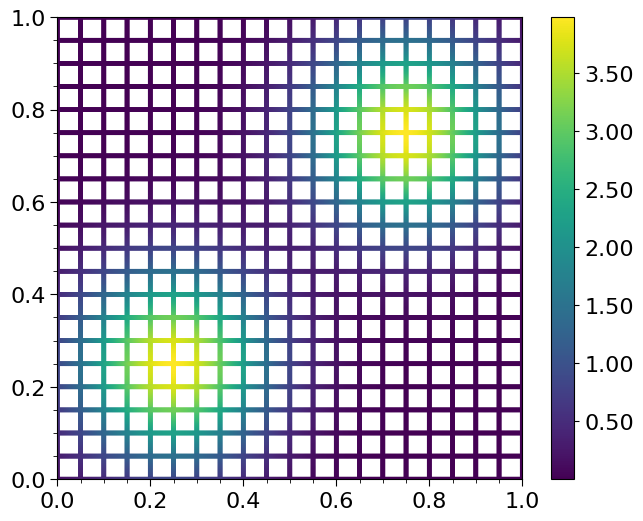

In [ ]:
plot_f_scatter(camel, 500, 42)


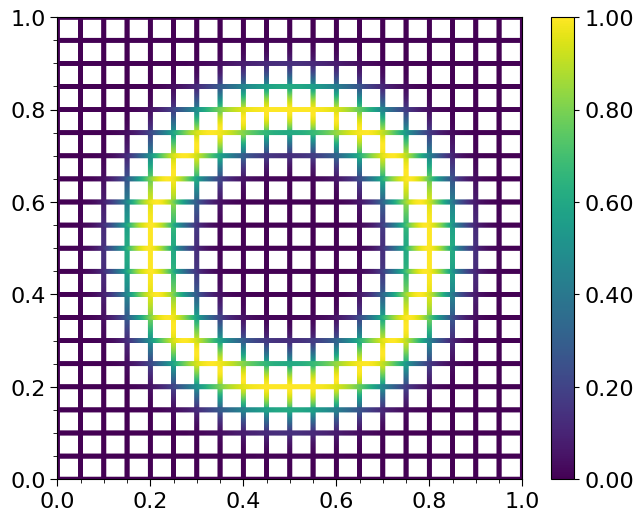

In [ ]:
plot_f_scatter(ring, 500, 42)

In [ ]:
def g_old(x, params, bins):

  '''
  New transform function generalised to deal with batches from NN.
  Parameters/bins can still be specified in the old way for testing by using an expanded tensor.
  x:      (B. D)
  params: (B, D, K-1)
  bins:   (B, D, K+1)
  '''

  device = x.device
  dtype = x.dtype

  B, D = x.shape
  K = params.size(-1) + 1

  #cdf heights
  zeros = torch.zeros((B, D, 1), device=device, dtype=dtype)
  ones = torch.ones((B, D, 1), device=device, dtype=dtype)
  heights = torch.cat([zeros, params, ones], dim=-1)

  # Find bin index via comparison
  # Compare x with bin edges

  x_expanded = x.unsqueeze(-1)  # (B, D, 1)

  # Count how many bin edges x is greater than
  i_values = torch.sum(x_expanded >= bins, dim=-1) - 1  # (B, D)
  i_values = torch.clamp(i_values, min=0)

  #i = torch.clamp(i, 0, K-1)
  i_values_right = torch.clamp(i_values + 1, max=K)

  i_unsq = i_values.unsqueeze(-1)
  i_right_unsq = i_values_right.unsqueeze(-1)   #(B, D, 1)

  x_left  = torch.gather(bins, dim=2, index=i_unsq).squeeze(-1)   #(B, D, 1) ---> (B, D)
  x_right = torch.gather(bins, dim=2, index=i_right_unsq).squeeze(-1)

  y_left  = torch.gather(heights, dim=2, index=i_unsq).squeeze(-1)
  y_right = torch.gather(heights, dim=2, index=i_right_unsq).squeeze(-1)    #(B, D, 1) ---> (B, D)

  slope = (y_right - y_left) / (x_right - x_left)
  y = y_left + slope * (x - x_left)

  return y    #(B, D)

In [ ]:
def g_coupling(x_A, x_B, heights, bins):

  '''
  Coupling-layer compatible transform.  Preserves x_A, transforms x_B.
  New transform function generalised to deal with batches from NN.
  Parameters/bins can still be specified in the old way for testing by using an expanded tensor.
  x_A:      (B, D_A)
  x_B:      (B, D_B)
  D_A, D_B are the dimensionalities of the two partitions.  Both can be greater than 1.
  D_A, D_B pre-determined by specific mask of coupling layer.
  heights: (B, D_B, K-1)
  bins:   (B, D_B, K+1)
  '''

  device = x_B.device
  dtype = x_B.dtype

  B, D_B = x_B.shape
  K = heights.size(-1) + 1

  #cdf heights
  zeros = torch.zeros((B, D_B, 1), device=device, dtype=dtype)
  ones = torch.ones((B, D_B, 1), device=device, dtype=dtype)
  cdf_heights = torch.cat([zeros, heights, ones], dim=-1)

  #----------------APPLY TRANSFORM TO x_B-----------------------------------#
  # Compare x_B with bin edges

  xB_expanded = x_B.unsqueeze(-1)  # (B, D_B, 1)

  # Count how many bin edges x_B is greater than
  i_values = torch.sum(xB_expanded >= bins, dim=-1) - 1  # (B, D_B)
  i_values = torch.clamp(i_values, min=0, max=K-1)

  i_values_right = i_values + 1

  i_unsq = i_values.unsqueeze(-1)
  i_right_unsq = i_values_right.unsqueeze(-1)   #(B, D_B, 1)

  x_left  = torch.gather(bins, dim=2, index=i_unsq).squeeze(-1)   #(B, D_B, 1) ---> (B, D_B)
  x_right = torch.gather(bins, dim=2, index=i_right_unsq).squeeze(-1)

  y_left  = torch.gather(cdf_heights, dim=2, index=i_unsq).squeeze(-1)
  y_right = torch.gather(cdf_heights, dim=2, index=i_right_unsq).squeeze(-1)    #(B, D_B, 1) ---> (B, D_B)

  slope = (y_right - y_left) / (x_right - x_left)
  y_B = y_left + slope * (x_B - x_left)

  #------------------------------------------------------------------------#

  y_A = x_A

  return y_A, y_B

In [ ]:
def expand_params(B, params):   #copies parameters to fit batch size
  '''
  params.shape = (D, K-1)
  returns (B, D, K-1)
  '''

  D = params.size(0)
  K = params.size(1) + 1
  expanded_params = torch.empty(B, D, K-1)
  expanded_params[:, :] = params
  return expanded_params

def expand_edges(B, edges):   #copies bin edges to fit batch size
  '''
  edges.shape = (D, K+1)
  returns (B, D, K+1)
  '''

  D = edges.size(0)
  K = edges.size(1) -1
  expanded_edges = torch.empty(B, D, K+1)
  expanded_edges[:, :] = edges
  return expanded_edges

#params = torch.rand(D, 7)
#edges = torch.rand(D, 8)
#print(expand_params(10, params))
#print(expand_edges(10, edges))

Defining functions for obtaining parameters and widths appropriate for the functions, from raw ones

In [ ]:
def raw_heights_to_params(raw_heights):
    """
    raw_heights: (B, D, K-1)

    Returns:
        params: (B, D, K-1)
        strictly increasing in last dimension,
        between 0 and 1.
    """

    device = raw_heights.device
    dtype = raw_heights.dtype

    B, D, K_minus_1 = raw_heights.shape

    # Append extra zero for normalization
    zeros = torch.zeros((B, D, 1), device=device, dtype=dtype)

    u_ext = torch.cat([raw_heights, zeros], dim=-1)  # (B, D, K)

    # Softmax along bin dimension
    w = torch.softmax(u_ext, dim=-1)  # (B, D, K)

    # Cumulative sum to get CDF
    ys = torch.cumsum(w, dim=-1)  # (B, D, K)

    # Remove last entry (which equals 1)
    return ys[..., :-1]  # (B, D, K-1)



def raw_widths_to_bins(raw_widths):
    """
    raw_widths: (B, D, K)

    Returns:
        bins: (B, D, K+1)
        increasing,
        starting at 0 and ending at 1.
    """

    device = raw_widths.device
    dtype = raw_widths.dtype

    # Softmax so widths sum to 1
    widths = torch.softmax(raw_widths, dim=-1)  # (B, D, K)

    # Cumulative sum gives interior edges
    int_edges = torch.cumsum(widths, dim=-1)  # (B, D, K)

    # Prepend zero
    zeros = torch.zeros((*int_edges.shape[:2], 1),
                        device=device, dtype=dtype)

    bins = torch.cat([zeros, int_edges], dim=-1)  # (B, D, K+1)

    return bins

In [ ]:
#test g

x_A = torch.rand(10, 1)
x_B = torch.rand(10, 2)   #D_B must match dimensionality of input heights and bins

print('x_A:', x_A)
print('x_B:', x_B)

old_heights = torch.tensor([[0.1, 0.25, 0.3, 0.4, 0.6, 0.7, 0.85],
                           [0.2, 0.35, 0.4, 0.5, 0.7, 0.8, 0.95]])

old_bins = torch.tensor([[0, 0.1, 0.2, 0.4, 0.5, 0.65, 0.8, 0.9, 1],
                          [0, 0.2, 0.3, 0.5, 0.65, 0.7, 0.75, 0.95, 1]])

expanded_heights = expand_params(10, old_heights)
expanded_bins = expand_edges(10, old_bins)

y_A, y_B = g_coupling(x_A, x_B, expanded_heights, expanded_bins)

print('y_A:', y_A)
print('y_B:', y_B)

x_A: tensor([[0.9764],
        [0.3561],
        [0.0962],
        [0.0905],
        [0.4720],
        [0.0408],
        [0.2194],
        [0.0535],
        [0.9351],
        [0.4907]])
x_B: tensor([[0.3353, 0.2630],
        [0.4790, 0.7483],
        [0.4354, 0.3514],
        [0.9865, 0.1650],
        [0.2925, 0.2129],
        [0.1266, 0.8833],
        [0.7202, 0.6464],
        [0.0253, 0.2410],
        [0.1381, 0.8071],
        [0.3903, 0.1737]])
y_A: tensor([[0.9764],
        [0.3561],
        [0.0962],
        [0.0905],
        [0.4720],
        [0.0408],
        [0.2194],
        [0.0535],
        [0.9351],
        [0.4907]])
y_B: tensor([[0.2838, 0.2945],
        [0.3790, 0.7965],
        [0.3354, 0.3628],
        [0.9798, 0.1650],
        [0.2731, 0.2194],
        [0.1399, 0.8999],
        [0.6468, 0.4976],
        [0.0253, 0.2616],
        [0.1571, 0.8428],
        [0.2976, 0.1737]])


In [ ]:
def plot_g(B, D, params, bins, dim):
  '''
  Plots g(x) for all samples.
  B: batch size
  D: number of dimensions
  params: (B, D, K-1)
  bins:   (B, D, K+1)
  dim starts at 0
  '''

  x_plot = torch.rand(B, D)
  x_plot = x_plot.sort(dim=0).values
  K = params.size(-1) + 1

  g_plot = g_new(x_plot, )


  #come back to these

In [ ]:
def h_coupling(y_A, y_B, A_dims, B_dims, heights, bins, f):   # this function in full generality not actually needed any more for coupling layers

  '''
  Coupling-layer compatible.
  Resulting function when the piecewise warp is applied, in accordance with the change of variables formula.
  Integral should be preserved.
  Non-uniform bins permitted.
  y_A:      (B, D_A)
  y_B:      (B, D_B)
  A_dims and B_dims contain the indices of the original dimensions that the rows in y_A and y_B
   (and x_A and x_B) correspond to.  A_dims: (D_A,), B_dims: (D_B,).
  heights:  (B, D_B, K-1)
  bins:     (B, D_B, K+1)
  '''

  device = y_A.device
  dtype = y_B.dtype

  D_A = y_A.size(-1)
  B, D_B = y_B.shape
  K = heights.size(-1) + 1

  #cdf heights
  zeros = torch.zeros((B, D_B, 1), device=device, dtype=dtype)
  ones = torch.ones((B, D_B, 1), device=device, dtype=dtype)
  cdf_heights = torch.cat([zeros, heights, ones], dim=-1)

  #---------y_A = x_A so only need to do inverse for y_B--------------------#

  #sort y_B by comparing y_B with cdf heights
  yB_expanded = y_B.unsqueeze(-1)  # (B, D_B, 1)

  j_values = torch.sum(yB_expanded >= cdf_heights, dim=-1) - 1  #(B, D_B)
  j_values = torch.clamp(j_values, min=0, max=K-1)

  j_values_right = j_values + 1

  j_unsq = j_values.unsqueeze(-1)
  j_right_unsq = j_values_right.unsqueeze(-1)

  x_left = torch.gather(bins, dim=2, index=j_unsq).squeeze(-1)    #(B, D_B, 1) ---> (B, D_B)
  x_right = torch.gather(bins, dim=2, index=j_right_unsq).squeeze(-1)
  y_left = torch.gather(cdf_heights, dim=2, index=j_unsq).squeeze(-1)
  y_right = torch.gather(cdf_heights, dim=2, index=j_right_unsq).squeeze(-1)

  def g_inv(y):

    return x_left + ((x_right - x_left) / (y_right - y_left)) * (y - y_left)    #(B, D_B)

  jacobians = (x_right - x_left) / (y_right - y_left)   #(B, D_B)

  arg_B = g_inv(y_B)

  #-------------------------------------------------------------------------#

  #Reconstruct full y vector to evaluate original function with, while preserving order

  args = torch.empty((D_A + D_B), B)
  args[A_dims] = y_A.T
  args[B_dims] = arg_B.T

  jac_det = jacobians.prod(dim=1)

  return f(*args) * jac_det

In [ ]:
def inverse_transform(y_B, B_dims, heights, bins):

  '''
  Computes the inverse transform and associated Jacobian.
  Non-uniform bins permitted.
  y_B:      (B, D_B)
  '''

  device = y_B.device
  dtype = y_B.dtype

  B, D_B = y_B.shape
  K = heights.size(-1) + 1

  #cdf heights
  zeros = torch.zeros((B, D_B, 1), device=device, dtype=dtype)
  ones = torch.ones((B, D_B, 1), device=device, dtype=dtype)
  cdf_heights = torch.cat([zeros, heights, ones], dim=-1)

  #---------y_A = x_A so only need to do inverse for y_B--------------------#

  #sort y_B by comparing y_B with cdf heights
  yB_expanded = y_B.unsqueeze(-1)  # (B, D_B, 1)

  j_values = torch.sum(yB_expanded >= cdf_heights, dim=-1) - 1  #(B, D_B)
  j_values = torch.clamp(j_values, min=0, max=K-1)

  j_values_right = j_values + 1

  j_unsq = j_values.unsqueeze(-1)
  j_right_unsq = j_values_right.unsqueeze(-1)

  x_left = torch.gather(bins, dim=2, index=j_unsq).squeeze(-1)    #(B, D_B, 1) ---> (B, D_B)
  x_right = torch.gather(bins, dim=2, index=j_right_unsq).squeeze(-1)
  y_left = torch.gather(cdf_heights, dim=2, index=j_unsq).squeeze(-1)
  y_right = torch.gather(cdf_heights, dim=2, index=j_right_unsq).squeeze(-1)

  def g_inv(y):

    return x_left + ((x_right - x_left) / (y_right - y_left)) * (y - y_left)    #(B, D_B)

  jacobians = (x_right - x_left) / (y_right - y_left)   #(B, D_B)

  jac_det = jacobians.prod(dim=1)

  return g_inv(y_B), jac_det

In [ ]:
from numpy import exp
#debugging inverse -- reference value 0.924368 for camel function
n = 200000
A_dims = torch.tensor([0])
B_dims = torch.tensor([1])

y = torch.rand(n, 2)

# Fix: Generate heights and bins for D_B = 1 to match x_B's dimensionality
#heights = raw_heights_to_params(torch.rand(1, 1, 7).repeat(n,1,1)) # Changed from (10, 2, 7)
#bins = raw_widths_to_bins(torch.rand(1, 1, 9).repeat(n,1,1))       # Changed from (10, 2, 9)

#alternative heights, bins

test_heights_2 = torch.tensor([[0.1, 0.2, 0.35, 0.4, 0.5, 0.7, 0.8]])
test_bins_2 = torch.tensor([[0, 0.2, 0.3, 0.35, 0.5, 0.6, 0.7, 0.85, 1]])
heights_2 = expand_params(n, test_heights_2)
bins_2 = expand_edges(n, test_bins_2)

#partition x
#x_A = x[:, 0].unsqueeze(1)
#x_B = x[:, 1].unsqueeze(1)
#print("x_B: ", x_B)

#do transforms
#y_A, y_B = g_coupling(x_A, x_B, heights_2, bins_2)

y_A = y[:, 0].unsqueeze(1)
y_B = y[:, 1].unsqueeze(1)

x_B_rec, jac_det = inverse_transform(y_B, B_dims, heights_2, bins_2)

#print("x_B from inverse: ", x_B_rec)

#recombine
x_rec = torch.zeros_like(x)
x_rec[:, 0] = y_A.squeeze()
x_rec[:, 1] = x_B_rec.squeeze() # Apply .squeeze() here to match dimensions

#print((x_rec - x).abs().max())

x_rec = x_rec.T

#integral before and after

test_before = camel(*y.T)
F_estimate_before = torch.mean(test_before)
error_before = torch.std(test_before) / torch.sqrt(torch.tensor(n))
print(f'F estimate before = {F_estimate_before} ± {error_before}')

test_after = camel(*x_rec) * jac_det
H_estimate_after = torch.mean(test_after)
error_after = torch.std(test_after) / torch.sqrt(torch.tensor(n))
print(f'H estimate after = {H_estimate_after} ± {error_after}')


F estimate before = 0.9216979146003723 ± 0.002357136458158493
H estimate after = 0.9235676527023315 ± 0.0029502036049962044


In [ ]:
#testing unpacking syntax and preserving dim order

y_A = torch.rand(10, 3)
y_B = torch.rand(10, 2)

print('y_A:', y_A)
print('y_B:', y_B)

A_dims = torch.tensor([0, 2, 4])
B_dims = torch.tensor([1, 3])
print(A_dims.shape)

args = torch.empty(3+2, 10)
args[A_dims] = y_A.T
args[B_dims] = y_B.T

print(args)

y_A: tensor([[0.0522, 0.1113, 0.9997],
        [0.9431, 0.5832, 0.1164],
        [0.5669, 0.6122, 0.7346],
        [0.4612, 0.5733, 0.0757],
        [0.2814, 0.9359, 0.4108],
        [0.5444, 0.2041, 0.8149],
        [0.7425, 0.8713, 0.2448],
        [0.1192, 0.9670, 0.4106],
        [0.9197, 0.3091, 0.5691],
        [0.4809, 0.9223, 0.2707]])
y_B: tensor([[0.1801, 0.3018],
        [0.0849, 0.7645],
        [0.2352, 0.6419],
        [0.7079, 0.6936],
        [0.6937, 0.4384],
        [0.2828, 0.3831],
        [0.6058, 0.0277],
        [0.1408, 0.7796],
        [0.2470, 0.7822],
        [0.9728, 0.5095]])
torch.Size([3])
tensor([[0.0522, 0.9431, 0.5669, 0.4612, 0.2814, 0.5444, 0.7425, 0.1192, 0.9197,
         0.4809],
        [0.1801, 0.0849, 0.2352, 0.7079, 0.6937, 0.2828, 0.6058, 0.1408, 0.2470,
         0.9728],
        [0.1113, 0.5832, 0.6122, 0.5733, 0.9359, 0.2041, 0.8713, 0.9670, 0.3091,
         0.9223],
        [0.3018, 0.7645, 0.6419, 0.6936, 0.4384, 0.3831, 0.0277, 0.7796, 0.

This section checks that the integral of the function is preserved under the transformation

In [ ]:
D = 2
test_heights = torch.tensor([[0.1, 0.2, 0.35, 0.4, 0.5, 0.7, 0.8],
                            [0.2, 0.3, 0.5, 0.6, 0.8, 0.85, 0.9]])

test_heights_2 = torch.tensor([[0.1, 0.2, 0.35, 0.4, 0.5, 0.7, 0.8]])

test_bins = torch.tensor([0, 0.2, 0.3, 0.35, 0.5, 0.6, 0.7, 0.85, 1]).repeat(D, 1)
test_bins_2 = torch.tensor([[0, 0.2, 0.3, 0.35, 0.5, 0.6, 0.7, 0.85, 1]])


N = 1000000
'''
REFERENCE VALUES OF INTEGRALS (WHERE POSSIBLE)

0.0019687   (3d Gaussian)
0.924386    (Camel)

'''

def MC_F(N, f):
  x = torch.rand(D, N)
  f_evals = f(*x)
  F_est = torch.mean(f_evals)
  alpha_F = torch.std(f_evals) / torch.sqrt(torch.tensor(N))
  return F_est, alpha_F

def MC_H(B, heights, bins, f):    #coupling friendly
  exp_heights = expand_params(B, heights)
  exp_bins = expand_edges(B, bins)
  ys = torch.rand(B, D)
  y_A = ys[:, 0].unsqueeze(1)
  y_B = ys[:, 1].unsqueeze(1)
  A_dims, B_dims = torch.tensor([0]), torch.tensor([1])
  h_evals = h_coupling(y_A, y_B, A_dims, B_dims, exp_heights, exp_bins, f)
  H_est = torch.mean(h_evals)
  alpha_H = torch.std(h_evals) / torch.sqrt(torch.tensor(N))
  return H_est, alpha_H


F_est, alpha_F = MC_F(N, ring)
print(f'F estimate = {F_est} ± {alpha_F}')

H_est, alpha_H = MC_H(N, test_heights_2, test_bins_2, ring)
print(f'H estimate = {H_est} ± {alpha_H}')


#can histogram results if needed

F estimate = 0.2366315722465515 ± 0.00033390449243597686
H estimate = 0.23602300882339478 ± 0.00042500958079472184


Defining the neural networks which return the raw cdf heights and raw bin widths respectively

In [ ]:
#neural network for cdf heights V

class flownet_V(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):

    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_size, out_features=hidden_size),
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=hidden_size),   #only one hidden layer for now
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=output_size),
    )

  def forward(self, x):
        return self.linear_layer_stack(x)



#neural network for bin widths W

class flownet_W(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):

    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_size, out_features=hidden_size),
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=hidden_size),   #only one hidden layer for now
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=output_size),
    )

  def forward(self, x):
        return self.linear_layer_stack(x)

In [ ]:
#testing D_B

D_A = 1
D_B = 3
K = 8

x_A = torch.rand(10, 1)

model_0 = flownet_V(input_size=D_A, hidden_size=16, output_size=D_B*(K-1))
model_1 = flownet_W(input_size=D_A, hidden_size=16, output_size=D_B*K)

raw_heights = model_0(x_A).reshape(10, D_B, K-1)
raw_widths = model_1(x_A).reshape(10, D_B, K)

print(raw_heights.shape)
print(raw_widths.shape)

torch.Size([10, 3, 7])
torch.Size([10, 3, 8])


Define a layer class which contains a NN for CDF heights and widths respectively (generalisation of the above), and a composition class which chains together an arbitrary number of coupling layers.

In [ ]:
class pwl_layer(nn.Module):
  '''
  A self-contained piecewise-linear coupling layer.
  Includes forward transform, inverse transform and Jacobian determinant functions.
  '''
  def __init__(self, D_A, D_B, A_dims, B_dims, K, hidden_size):

    super().__init__()

    #attributes

    self.D_A = D_A
    self.D_B = D_B
    self.K = K
    self.register_buffer("A_dims", A_dims)
    self.register_buffer("B_dims", B_dims)

    #networks

    self.heights_net = flownet_V(input_size=D_A, hidden_size=hidden_size, output_size=D_B*(K-1))

    self.widths_net = flownet_W(input_size=D_A, hidden_size=hidden_size, output_size=D_B*K)


  def forward(self, x):

    B = x.size(0)

    x_A = x[:, self.A_dims]   #apply mask
    x_B = x[:, self.B_dims]

    raw_heights = self.heights_net(x_A).reshape(B, self.D_B, (self.K - 1))    #evaluate neural networks with x_A
    raw_widths = self.widths_net(x_A).reshape(B, self.D_B, self.K)

    heights = raw_heights_to_params(raw_heights)
    bins = raw_widths_to_bins(raw_widths)

    y_A, y_B = g_coupling(x_A, x_B, heights, bins)    #apply the transform to x_B

    #reconstruct the y vector

    y = torch.zeros_like(x)
    y[:, self.A_dims] = y_A
    y[:, self.B_dims] = y_B

    return y


  def inverse(self, y):

    B = y.size(0)

    y_A = y[:, self.A_dims]
    y_B = y[:, self.B_dims]

    raw_heights = self.heights_net(y_A).reshape(B, self.D_B, (self.K - 1))    #evaluate neural networks with x_A
    raw_widths = self.widths_net(y_A).reshape(B, self.D_B, self.K)

    heights = raw_heights_to_params(raw_heights)
    bins = raw_widths_to_bins(raw_widths)

    x_B, jac_det = inverse_transform(y_B, self.B_dims, heights, bins)
    x_A = y_A

    x = torch.zeros_like(y)
    x[:, self.A_dims] = x_A
    x[:, self.B_dims] = x_B

    return x, jac_det


In [ ]:
class Composition(nn.Module):
  '''
  Composes the specified coupling layers and has the same functions as its constitients but generalised.
  '''

  def __init__(self, layers):

    super().__init__()

    self.layers = nn.ModuleList(layers)

  def forward(self, x):

    Y = x

    for layer in self.layers:

      Y = layer(Y)

    return Y

  def inverse(self, y):

    #we need to iterate backwards

    X = y
    jac_dets = torch.ones(y.shape[0], device=y.device, dtype=y.dtype)

    for layer in reversed(list(self.layers)):

      X, jac = layer.inverse(X)
      jac_dets = jac_dets * jac

    return X, jac_dets


In [ ]:
A_dims_test = [torch.tensor([0, 1]),   #A dimensions in first layer
               torch.tensor([2, 3, 1]), #2nd
               torch.tensor([0, 2]),   #3rd
               torch.tensor([1, 3])]  #4th

B_dims_test = [torch.tensor([2, 3]),
               torch.tensor([0]),
               torch.tensor([1, 3]),
               torch.tensor([0, 2])]

print(A_dims_test)
print(A_dims_test[0])
print(len(A_dims_test))
print(A_dims_test[1].size(-1))

[tensor([0, 1]), tensor([2, 3, 1]), tensor([0, 2]), tensor([1, 3])]
tensor([0, 1])
4
3


In [ ]:
#testing flow function first

num_layers = 4
#A_sizes, B_sizes = torch.zeros([num_layers, 1]), torch.zeros([num_layers, 1])
#print(A_sizes.shape)
for i in range(num_layers):

  D_A = A_dims_test[i].size(-1)
  D_B = B_dims_test[i].size(-1)

  print(D_A)
  print(D_B)

2
2
2
2
2
2
2
2


Now define a function which builds a normalising flow by specifying masks and layers, using the previous objects

In [ ]:
def normalising_flow(layer_type, A_dims, B_dims, K, hidden_size):

  '''
  Works for arbitrary dimensions, masks, layers.
  A_dims, B_dims are lists of tensors containing the indices of the relevant dimensions - the maskings.
  K is the number of bins for the piecewise-linear transformation.
  hidden_size is the number of nodes in the hidden layer(s) of the neural networks.
  Returns the Composition object corresponding to the inputs.
  '''

  num_layers = len(A_dims)
  layers = []

  for i in range(num_layers):   #build layers

    D_A = A_dims[i].size(-1)    #get D_A, D_B
    D_B = B_dims[i].size(-1)

    layer = layer_type(
        D_A = D_A,
        D_B = D_B,
        A_dims = A_dims[i],
        B_dims = B_dims[i],
        K = K,                  #using same K for each layer for now
        hidden_size = hidden_size
    )

    layers.append(layer)


  c = Composition(layers)
  return c


Define training loop(s)

In [ ]:
#NEW TRAINING LOOP FOR COMPOSITION

def train_loop_complete(f, D, layer_type, A_dims, B_dims, K, hidden_size, N, epochs, lr, device, ticker):    #using same K for each layer for now

  #instantiate flow with specified parameters
  flow = normalising_flow(
      layer_type,
      A_dims=A_dims,
      B_dims=B_dims,
      K=K,
      hidden_size=hidden_size
  )

  #optimiser
  optimiser = torch.optim.Adam([
      {"params": flow.parameters(), "lr": lr}
      ])

  loss_values = torch.zeros(epochs, device=device)

  for epoch in range(epochs):

    V = torch.rand(N, D)

    #inverse, jacobian determinants
    X, jac_dets = flow.inverse(V)

    #compute new function
    X = X.T
    h_eval = f(*X) * torch.abs(jac_dets)

    #compute loss
    loss = torch.var(h_eval)
    loss_values[epoch] = loss.detach()

    optimiser.zero_grad()

    loss.backward()

    optimiser.step()

    if ticker and epoch % 20 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.8e}")
      print("Mean value: ", torch.mean(h_eval).detach().item())

  final_loss = loss.detach()

  return final_loss, loss_values, flow


Testing the composition method

In [ ]:
#testing new loop - define parameters first

A_dims = [torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([0]),
          torch.tensor([1])]

B_dims = [torch.tensor([1]),
          torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([0])]

In [ ]:
#train

final_loss, loss_values, flow = train_loop_complete(
    layer_type=pwl_layer,
    f=ring,
    D=2,
    A_dims=A_dims,
    B_dims=B_dims,
    K=32,
    hidden_size=16,
    N=10_000,
    epochs=1500,
    lr=1e-4,
    device='cpu',
    ticker=True
)

Epoch: 0 | Loss: 2.28866771e-01
Mean value:  0.24356703460216522
Epoch: 20 | Loss: 1.84693307e-01
Mean value:  0.23524731397628784
Epoch: 40 | Loss: 1.70414612e-01
Mean value:  0.2359500527381897
Epoch: 60 | Loss: 1.65773869e-01
Mean value:  0.23979049921035767
Epoch: 80 | Loss: 1.56246439e-01
Mean value:  0.24506528675556183
Epoch: 100 | Loss: 1.43452182e-01
Mean value:  0.24073171615600586
Epoch: 120 | Loss: 1.30409539e-01
Mean value:  0.23757518827915192
Epoch: 140 | Loss: 1.22387908e-01
Mean value:  0.23411664366722107
Epoch: 160 | Loss: 1.15606673e-01
Mean value:  0.23649750649929047
Epoch: 180 | Loss: 1.11180589e-01
Mean value:  0.23437748849391937
Epoch: 200 | Loss: 1.07975200e-01
Mean value:  0.23502954840660095
Epoch: 220 | Loss: 1.04172923e-01
Mean value:  0.23658525943756104
Epoch: 240 | Loss: 9.81823877e-02
Mean value:  0.23587505519390106
Epoch: 260 | Loss: 9.65826064e-02
Mean value:  0.2323787659406662
Epoch: 280 | Loss: 9.31302756e-02
Mean value:  0.23857207596302032
Epo

In [ ]:
#evaluate using my own grid

Y = grid_points(1000, density=42)

X, jacs = flow.inverse(Y)
X, jacs = X.detach(), jacs.detach()
X = X.T

h = ring(*X) * torch.abs(jacs)


In [ ]:
#DEBUGGING - testing flow

test_x = torch.rand(10, 2)
print("x: ", test_x)

test_y = flow(test_x)
print("y: ", test_y)

x_rec, jacobian = flow.inverse(test_y)
print("x from inverse: ", x_rec)
print("jacobian: ", jacobian)


x:  tensor([[0.6068, 0.4937],
        [0.9086, 0.6503],
        [0.2364, 0.0180],
        [0.0671, 0.2380],
        [0.9784, 0.4153],
        [0.8172, 0.8107],
        [0.2208, 0.4110],
        [0.1277, 0.1758],
        [0.5756, 0.7678],
        [0.3348, 0.3964]])
y:  tensor([[0.6349, 0.4898],
        [0.9465, 0.5321],
        [0.3515, 0.0142],
        [0.0418, 0.3031],
        [0.9899, 0.2418],
        [0.7977, 0.8326],
        [0.1679, 0.5552],
        [0.1144, 0.1933],
        [0.3874, 0.8134],
        [0.3274, 0.5030]], grad_fn=<IndexPutBackward0>)
x from inverse:  tensor([[0.6068, 0.4937],
        [0.9086, 0.6503],
        [0.2364, 0.0180],
        [0.0671, 0.2380],
        [0.9784, 0.4153],
        [0.8172, 0.8107],
        [0.2208, 0.4110],
        [0.1277, 0.1758],
        [0.5756, 0.7678],
        [0.3348, 0.3964]], grad_fn=<IndexPutBackward0>)
jacobian:  tensor([1.0635, 0.9638, 0.6368, 0.6467, 1.7309, 0.3824, 0.7437, 0.4864, 0.7390,
        0.5390], grad_fn=<MulBackward0>)


In [ ]:
#check integral
N=100000
y_test = torch.rand(N, 2)
x_test, jacobian = flow.inverse(y_test)
x_test = x_test.detach().T

h_evals = camel(*x_test) * jacobian
print(h_evals.shape)

H_est = torch.mean(h_evals)
alpha_H = torch.std(h_evals) / torch.sqrt(torch.tensor(N))

print(f'H estimate = {H_est} ± {alpha_H}')

torch.Size([100000])
H estimate = 0.9241480231285095 ± 0.0016442746855318546


Plot distortion of grid under layers

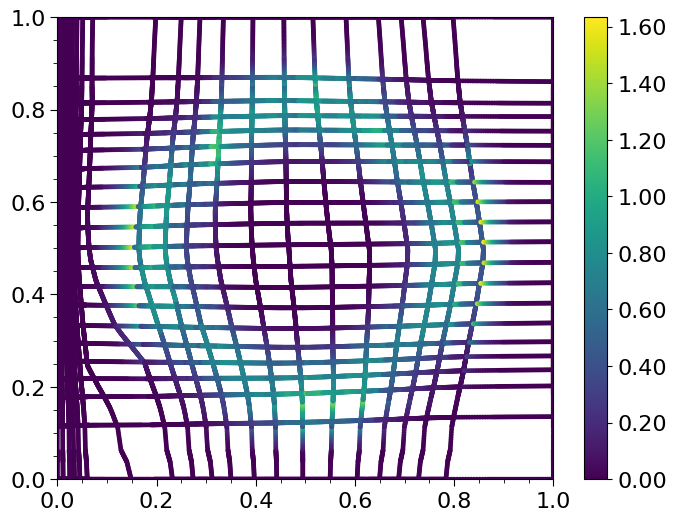

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
plot = ax.scatter(
  X[0].squeeze().cpu(),
  X[1].squeeze().cpu(),
  c=h.cpu(),
  s=6,
  cmap='viridis'
)
#ax.set_xlabel("$y_1$", fontsize=18)
#ax.set_ylabel("$y_2$", fontsize=18)

ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=16)
ax.tick_params(axis="both", which="minor", direction="out", length=3)
ax.minorticks_on()

cbar = plt.colorbar(plot, ax=ax)
cbar.formatter = ticker.FormatStrFormatter('%.2f')
cbar.ax.tick_params(labelsize=16)
cbar.update_ticks()

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)

plt.show()

Visualise the distribution in "x" space induced by the flow from sampling uniformly in "y" space

In [ ]:
num_samples = 200000

Y = torch.rand(num_samples, 2).to(device)

X, jacobians = flow.inverse(Y)
X = X.detach().cpu()

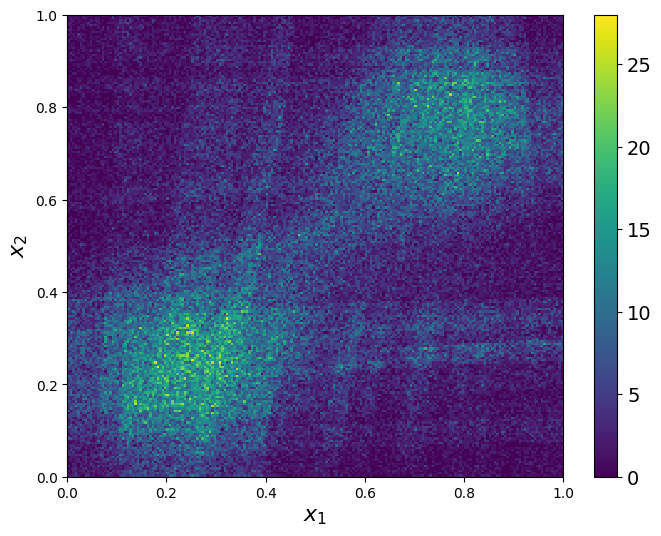

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

plot = ax.hist2d(
      X[:,0],
      X[:,1],
      bins=200,
      range=[[0,1],[0,1]],
      cmap = 'viridis'
)

cbar = plt.colorbar(plot[3], ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.update_ticks()

ax.set_xlabel("$x_1$", fontsize=16)
ax.set_ylabel("$x_2$", fontsize=16)

plt.show()

Plot importance weights

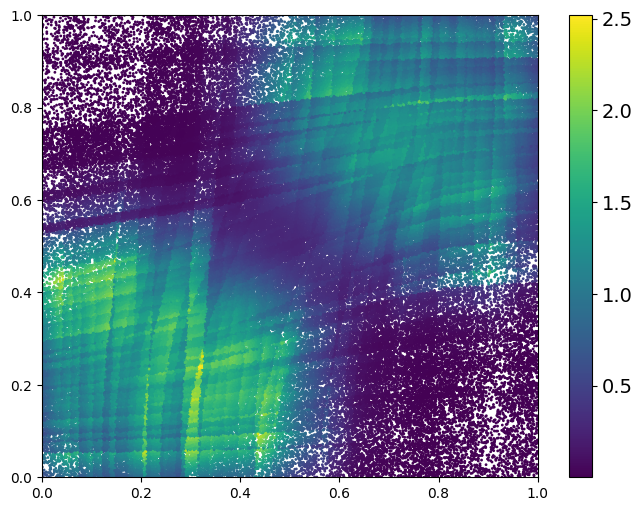

In [ ]:
weights = camel(X[:,0], X[:,1]) * torch.abs(jacobians)
weights = weights.detach().cpu()

fig, ax = plt.subplots(figsize=(8,6))

sc = ax.scatter(
    X[:,0],
    X[:,1],
    c=weights,
    s=1,
    cmap="viridis"
)

cbar = plt.colorbar(sc, ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.update_ticks()

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
plt.show()

OLD METHOD

Coupling layer 1

In [ ]:
#TEST LAYER SETUP#

D, D_A, D_B = 2, 1, 1
K = 32
B = 10_000    #batch size for training only

A_dims = torch.tensor([0])
B_dims = torch.tensor([1])    #so transforming 2nd dim only



Train neural networks

In [ ]:
final_loss, _, model_0, model_1 = train_loop_improved(
    f=camel,
    N=B,
    D_A=D_A,
    D_B=D_B,
    A_dims=A_dims,
    B_dims=B_dims,
    K=K,
    epochs=300,
    lr=0.003,
    device='cpu',
    ticker=True
)

print('Final loss: ', final_loss)

Epoch: 0 | Loss: 1.44483650e+00
Epoch: 10 | Loss: 1.27566063e+00
Epoch: 20 | Loss: 1.10405278e+00
Epoch: 30 | Loss: 9.36139882e-01
Epoch: 40 | Loss: 8.54741156e-01
Epoch: 50 | Loss: 7.82109380e-01
Epoch: 60 | Loss: 7.47559249e-01
Epoch: 70 | Loss: 6.76749408e-01
Epoch: 80 | Loss: 6.21817172e-01
Epoch: 90 | Loss: 5.50072372e-01
Epoch: 100 | Loss: 4.92165893e-01
Epoch: 110 | Loss: 4.49371368e-01
Epoch: 120 | Loss: 3.89030755e-01
Epoch: 130 | Loss: 3.61045867e-01
Epoch: 140 | Loss: 3.27489585e-01
Epoch: 150 | Loss: 3.09898704e-01
Epoch: 160 | Loss: 2.88019001e-01
Epoch: 170 | Loss: 2.71853864e-01
Epoch: 180 | Loss: 2.64010608e-01
Epoch: 190 | Loss: 2.47628704e-01
Epoch: 200 | Loss: 2.33788446e-01
Epoch: 210 | Loss: 2.24743381e-01
Epoch: 220 | Loss: 2.11959720e-01
Epoch: 230 | Loss: 2.02696726e-01
Epoch: 240 | Loss: 2.00208634e-01
Epoch: 250 | Loss: 1.97877631e-01
Epoch: 260 | Loss: 1.92183405e-01
Epoch: 270 | Loss: 1.92977056e-01
Epoch: 280 | Loss: 1.90226182e-01
Epoch: 290 | Loss: 1.8835

Define input array, evaluate NNs with x_A, apply transform to x_B

In [ ]:
X = grid_points(600, density=32)
x_A = X[:, 0].unsqueeze(1)
x_B = X[:, 1].unsqueeze(1)
print(x_A)
print(x_B.shape)

raw_heights_output = model_0(x_A).detach()
raw_bins_output = model_1(x_A).detach()

# Reshape raw_heights and raw_bins using the actual batch size from x_A
raw_heights = raw_heights_output.reshape(x_A.shape[0], D_B, K-1)
raw_bins = raw_bins_output.reshape(x_A.shape[0], D_B, K)

heights = raw_heights_to_params(raw_heights)
bins = raw_widths_to_bins(raw_bins)


y_A, y_B = g_coupling(x_A, x_B, heights, bins)
h_eval = h_coupling(y_A, y_B, A_dims, B_dims, heights, bins, camel)

tensor([[0.0000],
        [0.0000],
        [0.0000],
        ...,
        [0.9967],
        [0.9983],
        [1.0000]])
torch.Size([19200, 1])


In [ ]:
print(y_A)
print(y_B[25:])

tensor([[0.0000],
        [0.0000],
        [0.0000],
        ...,
        [0.9967],
        [0.9983],
        [1.0000]])
tensor([[0.0403],
        [0.0425],
        [0.0446],
        ...,
        [1.0000],
        [1.0000],
        [1.0000]])


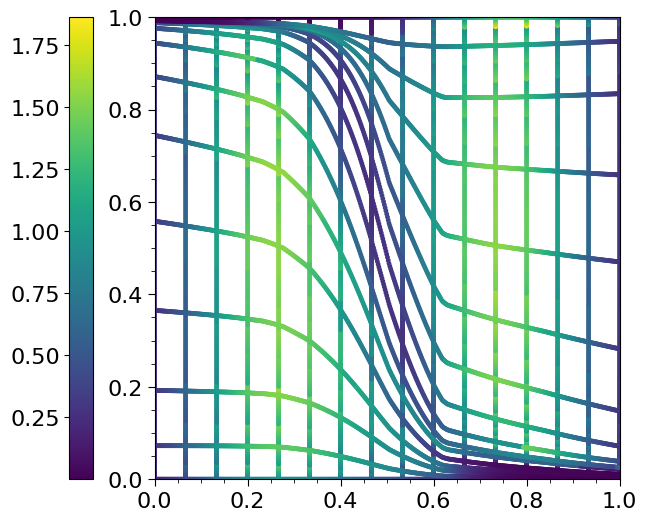

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
scat = ax.scatter(
  y_A.squeeze().cpu(),
  y_B.squeeze().cpu(),
  c=h_eval.cpu(),
  s=6,
  cmap='viridis'
)
#ax.set_xlabel("$y_1$", fontsize=14)
#ax.set_ylabel("$y_2$", fontsize=14)

ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=16)
ax.tick_params(axis="both", which="minor", direction="out", length=3)
ax.minorticks_on()

cbar = plt.colorbar(scat, ax=ax, location='left')
cbar.formatter = ticker.FormatStrFormatter('%.2f')
cbar.ax.tick_params(labelsize=16)
cbar.update_ticks()

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)

plt.show()

Coupling layer 2

In [ ]:
new_DA = 1
new_DB = 1

new_A_dims = torch.tensor([1])
new_B_dims = torch.tensor([0])    #transform other dimension this time

Train neural networks

In [ ]:
final_loss_2, _, model_2, model_3 = train_loop_improved(
    f=camel,
    N=B,
    D_A=new_DA,
    D_B=new_DB,
    A_dims=new_A_dims,
    B_dims=new_B_dims,
    K=K,
    epochs=300,
    lr=0.003,
    device='cpu',
    ticker=True
)

print('Final loss: ', final_loss)

Epoch: 0 | Loss: 2.19297814e+00
Epoch: 10 | Loss: 1.23027813e+00
Epoch: 20 | Loss: 1.02520287e+00
Epoch: 30 | Loss: 9.22265410e-01
Epoch: 40 | Loss: 8.41336012e-01
Epoch: 50 | Loss: 8.15160394e-01
Epoch: 60 | Loss: 7.73058414e-01
Epoch: 70 | Loss: 7.54763186e-01
Epoch: 80 | Loss: 7.24388182e-01
Epoch: 90 | Loss: 6.56550705e-01
Epoch: 100 | Loss: 5.84784865e-01
Epoch: 110 | Loss: 5.24381220e-01
Epoch: 120 | Loss: 4.64471579e-01
Epoch: 130 | Loss: 4.13656116e-01
Epoch: 140 | Loss: 3.63722175e-01
Epoch: 150 | Loss: 3.34667563e-01
Epoch: 160 | Loss: 3.13144386e-01
Epoch: 170 | Loss: 2.93266743e-01
Epoch: 180 | Loss: 2.82865316e-01
Epoch: 190 | Loss: 2.70156473e-01
Epoch: 200 | Loss: 2.60552675e-01
Epoch: 210 | Loss: 2.51384735e-01
Epoch: 220 | Loss: 2.46635467e-01
Epoch: 230 | Loss: 2.39222422e-01
Epoch: 240 | Loss: 2.37355039e-01
Epoch: 250 | Loss: 2.33347341e-01
Epoch: 260 | Loss: 2.29398504e-01
Epoch: 270 | Loss: 2.26199597e-01
Epoch: 280 | Loss: 2.20976174e-01
Epoch: 290 | Loss: 2.1497

Define new input array, evaluate NNs with new x_A, apply transform to new x_B

In [ ]:
#input = y_A, y_B

new_xA = y_B
new_xB = y_A    #roles have swapped

raw_heights_output = model_2(new_xA).detach()
raw_bins_output = model_3(new_xA).detach()

# Reshape raw_heights and raw_bins using the actual batch size from x_A
raw_heights = raw_heights_output.reshape(new_xA.shape[0], new_DB, K-1)
raw_bins = raw_bins_output.reshape(new_xA.shape[0], new_DB, K)

new_heights = raw_heights_to_params(raw_heights)
new_bins = raw_widths_to_bins(raw_bins)


new_y_A, new_y_B = g_coupling(new_xA, new_xB, new_heights, new_bins)
new_h_eval = h_coupling(new_y_A, new_y_B, new_A_dims, new_B_dims, new_heights, new_bins, camel)

In [ ]:
print(new_y_A)
print(new_y_B)

tensor([[0.0000],
        [0.0017],
        [0.0035],
        ...,
        [1.0000],
        [1.0000],
        [1.0000]])
tensor([[0.0000],
        [0.0000],
        [0.0000],
        ...,
        [0.9983],
        [0.9991],
        [1.0000]])


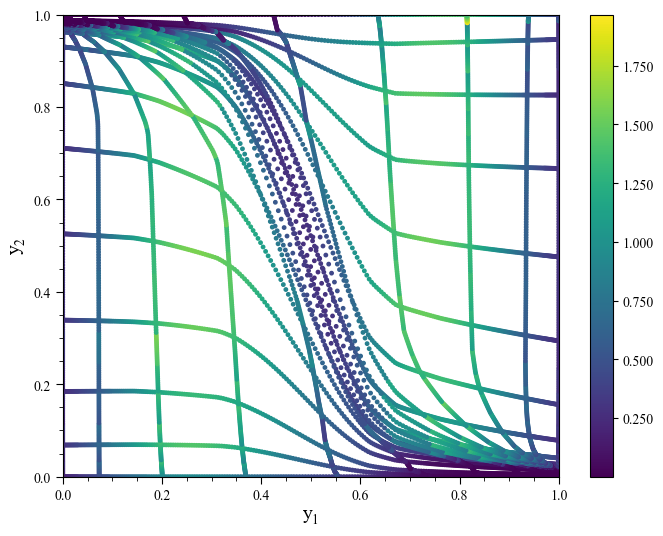

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
scat2 = ax.scatter(
  new_y_A.squeeze().cpu(),
  new_y_B.squeeze().cpu(),
  c=new_h_eval.cpu(),
  s=6,
  cmap='viridis'
)
ax.set_xlabel("$y_1$", fontsize=14)
ax.set_ylabel("$y_2$", fontsize=14)

ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=10)
ax.tick_params(axis="both", which="minor", direction="out", length=3)
ax.minorticks_on()

cbar = plt.colorbar(scat2, ax=ax)
cbar.formatter = ticker.FormatStrFormatter('%.3f')
cbar.update_ticks()

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)

plt.show()

In [ ]:
del model_0, model_1
torch.cuda.empty_cache()

In [ ]:
# Example of how to free up GPU memory

# Let's assume you have a large tensor on GPU
large_tensor = torch.randn(4096, 4096, device='cuda')
print(f"Memory allocated before freeing: {torch.cuda.memory_allocated() / (1024**2):.2f} MB")

# Delete the tensor when no longer needed
del large_tensor

# Explicitly empty the CUDA cache
torch.cuda.empty_cache()
print(f"Memory allocated after freeing: {torch.cuda.memory_allocated() / (1024**2):.2f} MB")

# You can also delete models
# del model_0
# del model_1
# torch.cuda.empty_cache()


This section is purely for visualisation/analysis tools - variation of loss with epoch, final loss vs number of bins, loss vs epoch for different learning rates, histogram of function evaluations for variance estimates.
NB the below plots have not been run on the steeper exponential defined at the beginning yet; they are for the original Gaussian.

Loss vs epoch for different K

D = 2

In [ ]:
#generate data

A_dims_test = [torch.tensor([0]),
          torch.tensor([1])]
B_dims_test = [torch.tensor([1]),
          torch.tensor([0])]

K_s = [2, 4, 8, 16, 32, 64, 128]
epochs = 1000
loss_values = torch.zeros((len(K_s), epochs), device=device, dtype=dtype)

results = {}  # K -> loss tensor

for K in K_s:
    _, losses, _ = train_loop_complete(
     f=camel,
     D=2,
     layer_type=pwl_layer,
     A_dims=A_dims_test,
     B_dims=B_dims_test,
     K=K,
     hidden_size=16,
     N=10_000,
     epochs=epochs,
     lr=3e-4,
     device=device,
     ticker=False
    )

    results[K] = losses.detach().cpu()

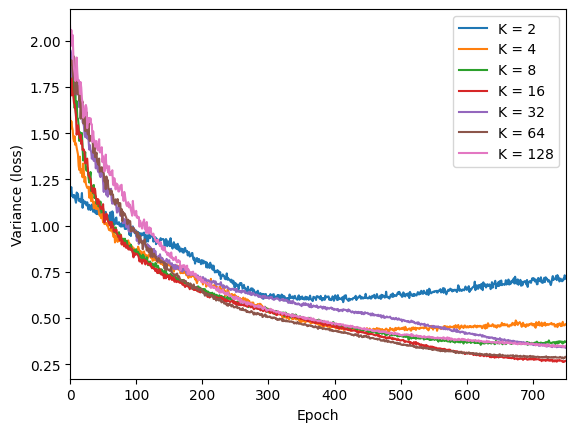

In [ ]:
#plotting for early stopping enabled

plt.figure()

for K, losses in results.items():
  epochs_plot = torch.arange(len(losses))
  plt.plot(epochs_plot, losses.numpy(), label=f"K = {K}")

plt.xlabel("Epoch")
plt.ylabel("Variance (loss)")
#plt.yscale("log")
plt.xlim(0, 750)
plt.legend()
plt.show()

Loss vs K

In [ ]:
#generate data

Ks = range(2, 129)
vars = torch.zeros(len(Ks), device=device)
i=0

for K in Ks:
  result, _, _ = train_loop_complete(
      f=camel,
      D=2,
      layer_type=pwl_layer,
      A_dims=A_dims_test,
      B_dims=B_dims_test,
      K=K,
      hidden_size=16,
      N=10_000,
      epochs=1000,
      lr=3e-4,
      device=device,
      ticker=False
  )

  vars[i] = result.reshape(1) # Reshape scalar to a 1D tensor
  i += 1

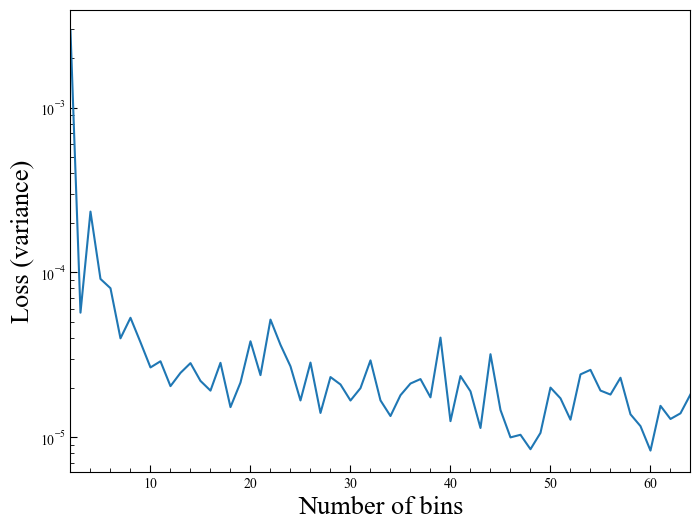

tensor(1.8189e-05)


In [ ]:
#plotting

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(Ks, vars.detach().numpy())  # Detach and convert to numpy for plotting

ax.set_xlabel("Number of bins", fontsize=19)
ax.set_ylabel("Loss (variance)", fontsize=19)

ax.tick_params(axis="both", which="major", direction="in", length=5, labelsize=10)
ax.tick_params(axis="both", which="minor", direction="in", length=3)
ax.minorticks_on()

ax.set_xlim(2, 64)
plt.yscale('log')
plt.show()
print(vars[-1])     #check accuracy

Loss vs epoch for different learning rates (not done for NN case yet)

In [ ]:
#generate data

K = 16
l_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5]
epochs=200
loss_values = torch.zeros((len(l_rates), epochs), device=device)

for i in range(len(l_rates)):
  loss_values[i] = train_loop_improved(x_test, K, epochs, lr=l_rates[i], device=device, ticker=False)[1]

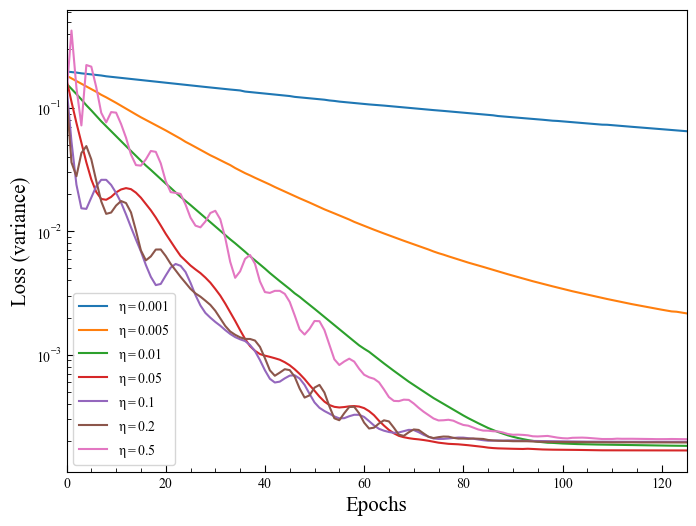

In [ ]:
#plotting

fig, ax = plt.subplots(figsize=(8, 6))

epochs_plot = torch.arange(epochs, device='cpu')
for i in range(len(l_rates)):
  ax.plot(epochs_plot, loss_values[i].detach().cpu().numpy(), label=rf"$\eta = {l_rates[i]}$")

ax.set_xlabel("Epochs", fontsize=15)
ax.set_ylabel("Loss (variance)", fontsize=15)

ax.tick_params(axis="both", which="major", direction="in", length=5, labelsize=10)
ax.tick_params(axis="both", which="minor", direction="in", length=3)
ax.minorticks_on()

ax.set_xlim(0, 125)

plt.legend()
plt.yscale('log')
plt.show()

SAVING FUNCTIONS TO DRIVE

In [ ]:
%%writefile /content/drive/MyDrive/nf_code/pwlinearNN.py

### INSERT CODE TO WRITE IN HERE ###

Overwriting /content/drive/MyDrive/nf_code/pwlinearNN.py
